# Enzyme Thermal Stability — Exploratory Data Analysis

Explores `data/brenda_features.csv`: BRENDA temperature-optimum records joined to UniProt sequences and protlearn sequence descriptors (produced by `scripts/parse_brenda.py` → `scripts/fetch_uniprot_sequences.py` → `scripts/extract_features.py`).

In [4]:
# Import packages for data manipulation
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# dataviz palette: single sequential hue (blue) + fixed categorical order
BLUE = "#2a78d6"
CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100",
               "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
plt.rcParams["axes.spines.top"] = False

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = "#52514e"
plt.rcParams["ytick.color"] = "#52514e"
plt.rcParams["grid.color"] = "#e1e0d9"

# Import dataset
df = pd.read_csv("../data/brenda_features.csv")
df.shape

/var/folders/n4/33s5r2kd7kzgyh8njb1qx_000000gn/T/ipykernel_30201/1958989896.py:27: DtypeWarning: Columns (0: temperature_optimum_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/brenda_features.csv")


(10719, 10320)

## Dataset overview

`brenda_features.csv` has one row per (EC number, organism, UniProt accession) record. The first columns are metadata/target; everything after `sequence_length` is a protlearn-derived numeric feature.

In [6]:
META_COLS = ["ec_number", "protein_number", "organism", "uniprot_accession",
             "temperature_optimum_c", "temperature_optimum_raw",
             "sequence", "sequence_length"]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f"{len(df):,} rows")
print(f"{len(META_COLS)} metadata/target columns, {len(FEATURE_COLS):,} feature columns")
df[META_COLS].head()

10,719 rows
8 metadata/target columns, 10,312 feature columns


,ec_number,protein_number,organism,uniprot_accession,temperature_optimum_c,temperature_optimum_raw,sequence,sequence_length
0,1.1.1.1,109,Saccharolobus solfataricus,P39462,80.0,80,MRAVRLVEIGKPLSLQEIGVPKPKGPQVLIKVEAAGVCHSDVHMRQ...,347.0
1,1.1.1.1,136,Haloferax volcanii,D4GSN2,80.0,80,MRAAVLREHGEPLDVTEVPDPTCDADGVVVEVEACGICRSDWHSWM...,353.0
2,1.1.1.1,163,Pyrobaculum calidifontis,A3MVR8,80.0,80,MRAAVIKEWGTPLEVTDVPKPEPGPGEVLVRISASGVCHTDIHQWK...,348.0
3,1.1.1.1,115,Thermoplasma acidophilum,Q9HIM3,75.0,75,MKAALVYEPLGNENLRIEDVDDPKVLDGQVLIEVRKAGLNPVDYNT...,328.0
4,1.1.1.1,126,Sulfolobus acidocaldarius,Q4J702,75.0,75,MDIDRLFSVKGMNAVVLGASSGIGKAIAEMFSEMGGKVVLSDIDEE...,264.0


## Missing data

protlearn feature blocks are computed only over the eligible subset of sequences (natural amino acids only, and long enough for lag/lambda-based descriptors); ineligible rows get NaN for that block. This shows how much of each block is missing.

Average missingness across all feature columns: 0.5%


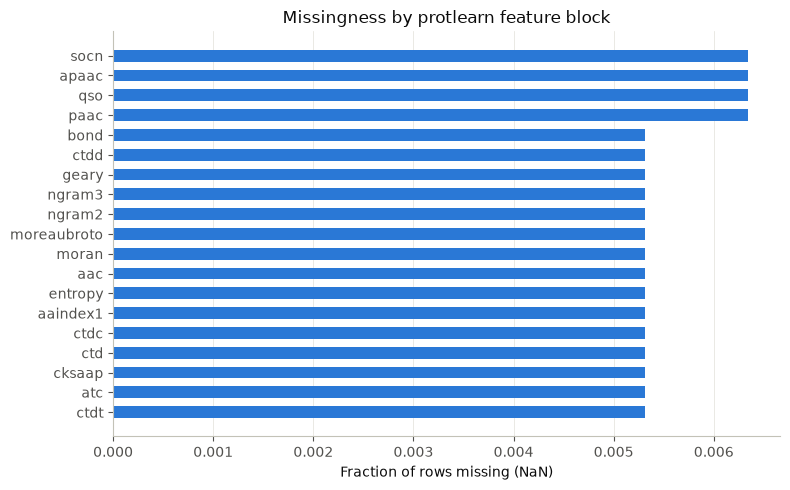

In [3]:
overall_missing = df[FEATURE_COLS].isna().mean().mean()
print(f"Average missingness across all feature columns: {overall_missing:.1%}")

# group feature columns by their block prefix (e.g. "aac", "aaindex1", "ctd", ...)
block_of = lambda c: c.split("_")[0]
block_missing = (
    df[FEATURE_COLS].isna().mean()
    .groupby(block_of)
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(block_missing.index[::-1], block_missing.values[::-1], color=BLUE, height=0.6)
ax.set_xlabel("Fraction of rows missing (NaN)")
ax.set_title("Missingness by protlearn feature block")
ax.grid(axis="x", linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [17]:
## Drop any row that has at least one missing (NaN) value
df = df.dropna()
df.shape

(10651, 10320)

## Target variable: temperature optimum (°C)

count    10651.000000
mean        40.380696
std         17.099819
min          0.000000
25%         30.000000
50%         37.000000
75%         45.000000
max        120.000000
Name: temperature_optimum_c, dtype: float64


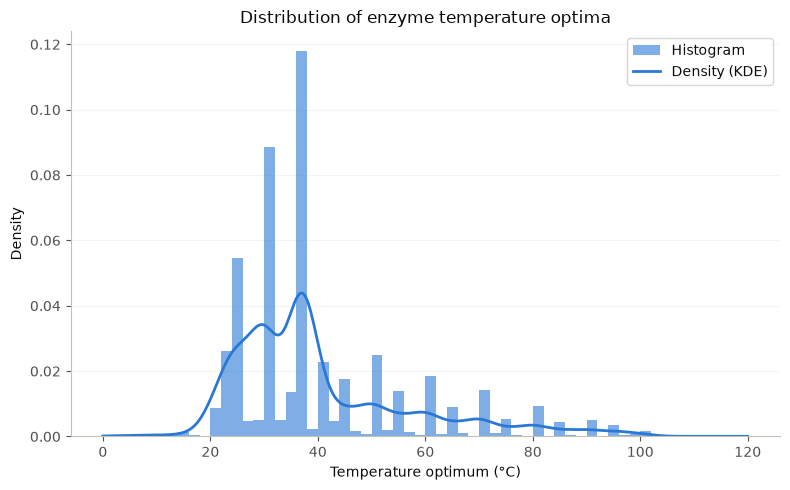

In [19]:
print(df["temperature_optimum_c"].describe())

fig, ax = plt.subplots(figsize=(8, 5))

data = df["temperature_optimum_c"].dropna()

# Histogram
ax.hist(data, bins=60, color=BLUE, alpha=0.6, density=True, label="Histogram")

# Density curve
kde = gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 500)
ax.plot(x_range, kde(x_range), color=BLUE, linewidth=2, label="Density (KDE)")

ax.set_xlabel("Temperature optimum (°C)")
ax.set_ylabel("Density")
ax.set_title("Distribution of enzyme temperature optima")
ax.grid(axis="y", linewidth=0.5)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()

## Organisms and EC numbers

Which organisms and enzyme classes dominate the dataset — useful context for reading any downstream model's errors (e.g. is it just learning a few well-represented thermophiles?).

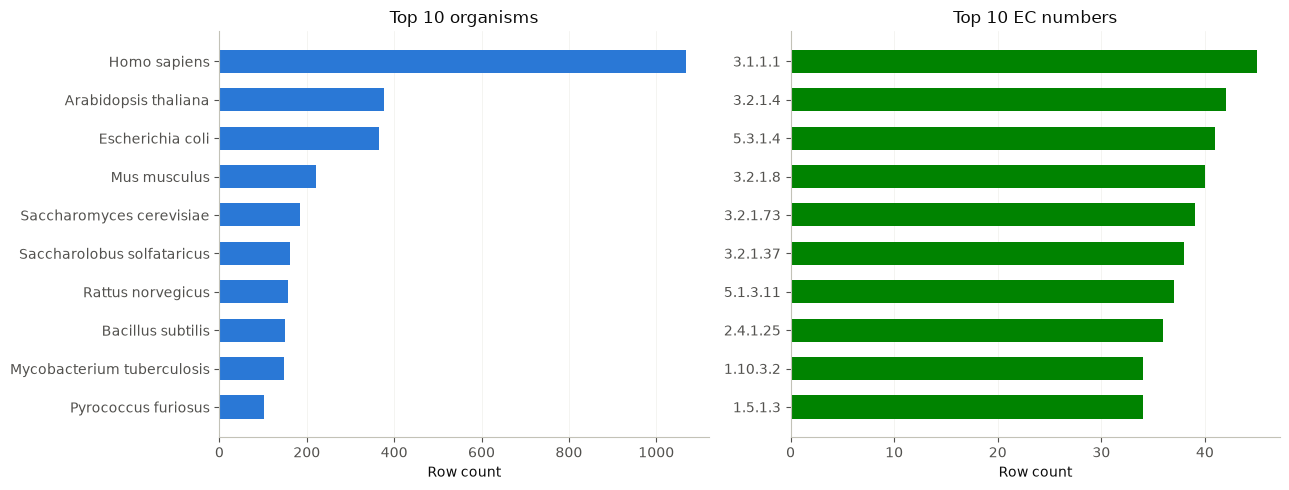

2,201 unique organisms, 2,931 unique EC numbers


In [29]:
top_organisms = df["organism"].value_counts().head(10)
top_ec = df["ec_number"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_organisms.index[::-1], top_organisms.values[::-1],
             color=CATEGORICAL[0], height=0.6)
axes[0].set_xlabel("Row count")
axes[0].set_title("Top 10 organisms")
axes[0].grid(axis="x", linewidth=0.5)
axes[0].set_axisbelow(True)

axes[1].barh(top_ec.index[::-1].astype(str), top_ec.values[::-1],
             color=CATEGORICAL[1], height=0.6)
axes[1].set_xlabel("Row count")
axes[1].set_title("Top 10 EC numbers")
axes[1].grid(axis="x", linewidth=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"{df['organism'].nunique():,} unique organisms, {df['ec_number'].nunique():,} unique EC numbers")

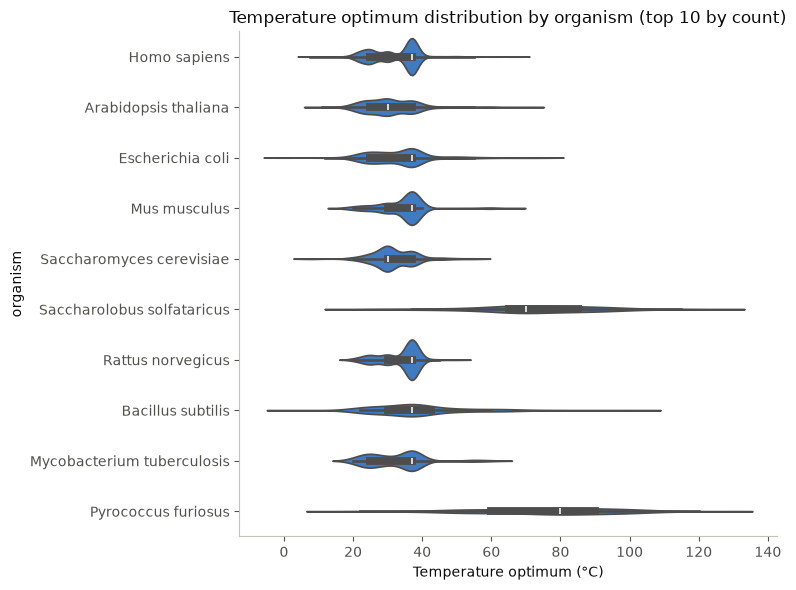

In [31]:
# Get top 10 organisms by count
top10_organisms = df["organism"].value_counts().head(10).index

# Filter dataframe to only those organisms
df_top10 = df[df["organism"].isin(top10_organisms)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=df_top10,
    x="temperature_optimum_c",
    y="organism",
    order=top10_organisms,  # keep them sorted by frequency
    ax=ax,
    color=BLUE,
)
ax.set_xlabel("Temperature optimum (°C)")
ax.set_title("Temperature optimum distribution by organism (top 10 by count)")
plt.tight_layout()
plt.show()

## Resampling

There are organism-level patterns - organisms with more enzyme entries dominate the distribution.

In [51]:
print(df.groupby("organism").agg(
    count=("organism", "size"),
    mean_temperature=("temperature_optimum_c", "mean")
).sort_values("count", ascending=False).head(100))

                              count  mean_temperature
organism                                             
Homo sapiens                   1067         32.364761
Arabidopsis thaliana            376         31.376330
Escherichia coli                366         33.586066
Mus musculus                    222         34.601351
Saccharomyces cerevisiae        184         31.697826
...                             ...               ...
Streptococcus mutans             14         36.214286
Bacillus methanolicus            14         38.535714
Fragaria x ananassa              14         32.000000
Dictyostelium discoideum         14         30.071429
Bacteroides thetaiotaomicron     14         38.250000

[100 rows x 2 columns]


## Feature correlations with the target

Simple Pearson correlation of each numeric feature column against `temperature_optimum_c`, ranked by absolute value. Highlights which protlearn descriptors move together with thermal stability on their own, before any modeling.

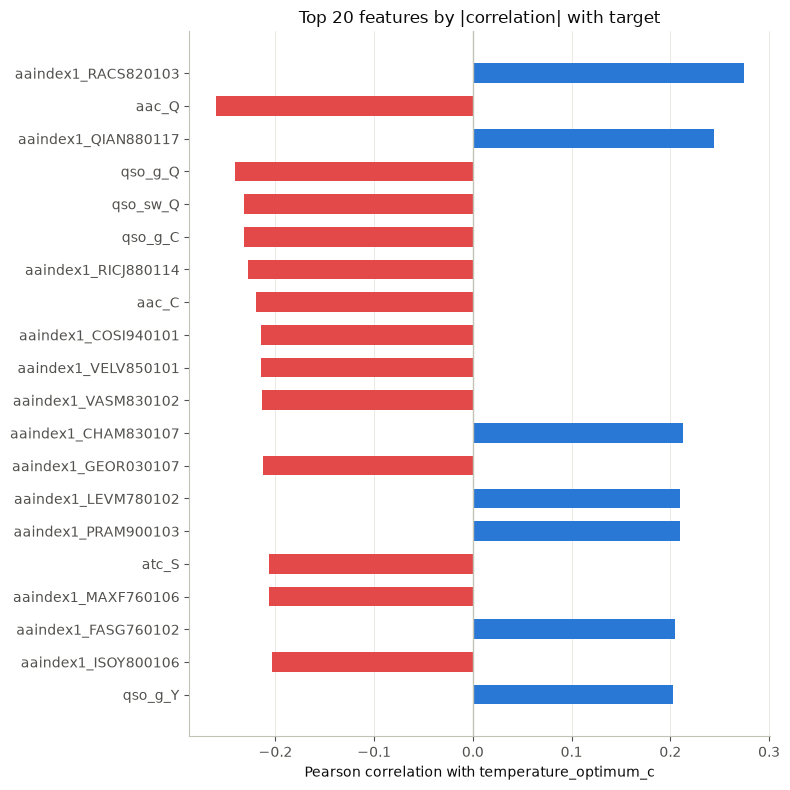

aaindex1_RACS820103    0.274292
aac_Q                 -0.260290
aaindex1_QIAN880117    0.244086
qso_g_Q               -0.241391
qso_sw_Q              -0.231885
qso_g_C               -0.231317
aaindex1_RICJ880114   -0.228215
aac_C                 -0.220068
aaindex1_COSI940101   -0.214197
aaindex1_VELV850101   -0.214173
aaindex1_VASM830102   -0.213462
aaindex1_CHAM830107    0.212973
aaindex1_GEOR030107   -0.212124
aaindex1_LEVM780102    0.209619
aaindex1_PRAM900103    0.209619
atc_S                 -0.206882
aaindex1_MAXF760106   -0.206769
aaindex1_FASG760102    0.204352
aaindex1_ISOY800106   -0.202934
qso_g_Y                0.202799
dtype: float64

In [7]:
corrs = (
    df[FEATURE_COLS]
    .corrwith(df["temperature_optimum_c"])
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
top_corrs = corrs.head(20)[::-1]

colors = [CATEGORICAL[0] if v >= 0 else CATEGORICAL[7] for v in top_corrs.values]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_corrs.index, top_corrs.values, color=colors, height=0.6)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Pearson correlation with temperature_optimum_c")
ax.set_title("Top 20 features by |correlation| with target")
ax.grid(axis="x", linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

top_corrs[::-1]